# pow benchmark — results and interpretation

Loads every `results/bench-*.json`, builds the per-N summary table, plots solve time vs N, tests the `Exp(λ)` model via ECDF/density and normalized diagnostics, and ends with a cross-implementation comparison.

Data loading, metrics, formatting and plots live in `_lib.py` next to this notebook; only narrative and call sites stay here. A compact view without methodology is in `explore_results_simple.ipynb`.

Outputs are checked in alongside the source so GitHub renders the figures and tables without re-execution.


## Methodology

Let $T$ be the raw challenge token and $n$ the ASCII-decimal nonce:

$$
H(n) = \mathrm{SHA256}(T \,\|\, \mathrm{ascii}_{10}(n)).
$$

A solution at difficulty $N$ satisfies $\mathrm{lzhex}(H(n)) \ge N$, where $\mathrm{lzhex}$ counts leading zero hex digits in the digest. The solver returns `(nonce, attempts, elapsed_secs, digest)`; `verify()` recomputes the hash independently. Both implementations share the wire format: raw token bytes followed by the ASCII decimal nonce.

For a uniform SHA-256 digest:

$$
p_N = 16^{-N}, \qquad \mathbb{E}[A_N] = 16^N.
$$

For hashrate $r$ (hashes/s):

$$
\mathbb{E}[T_N] = \frac{16^N}{r}, \qquad
\mathrm{median}(T_N) \approx \frac{\ln 2 \cdot 16^N}{r}.
$$

Two values of $r$ matter:

- $r_{\mathrm{calib}}$ — calibration hashrate from a tight `sha256` loop with no coordination. The expression $\ln 2 \cdot 16^N / r_{\mathrm{calib}}$ is a lower bound on median solve time.
- $r_{\mathrm{eff}}$ — pooled effective rate during solves, $\sum \mathrm{attempts} / \sum \mathrm{elapsed}$. This rate already absorbs coordination overhead and matches the empirical distribution.

For each $N$ in `[--start, --max]`, the benchmark generates a random 16-byte token and a random start nonce, solves the challenge, and records `attempts` and wall-clock `elapsed`. Rust uses a random `u64` start nonce; the Python baseline uses a random 32-bit offset. The benchmark repeats up to `--runs` times and stops early when the cumulative wall-clock for that $N$ exceeds `max(3 × target, 30 s)`.

The headline metric is the largest $N$ whose median solve time is at most `target_secs`. Equivalently: $\Pr(T \le \mathrm{target}) \ge 0.5$; the notebook reports both forms. Mean, p95 and p99 are diagnostics; near the target the per-N cap leaves too few samples for tail estimates to be stable, so p95 and stddev are masked below `MIN_RUNS_TAIL` runs.


In [1]:
from _lib import (
    load_runs,
    plot_diagnostics,
    plot_ecdf,
    plot_pdf,
    plot_solve_times_full,
    show_comparison,
    show_headline,
    show_table,
    summary_table,
)

runs = load_runs()

loaded 2 file(s) from /Users/pikachu/dev/pow/results
  bench-oniguruma-20260525T120719Z-shani.json: oniguruma/shani threads=32 target=60s N=6..9 rows=81
  bench-oniguruma-20260525T132118Z-python.json: oniguruma/python threads=1 target=60s N=4..7 rows=78


## Summary table

Per `(label, N)`: number of runs, median and mean elapsed, nearest-rank p95 (same rule as in the Rust/Python bench), stddev, effective hashrate. p95 and stddev are masked (`—`) when `runs < MIN_RUNS_TAIL = 20` — at that few samples those columns are dominated by individual outliers, not the underlying distribution. Times are rounded to 3 decimals; `eff_hps` is rendered as a plain integer with space-thousand separators.


In [2]:
show_table(summary_table(runs))

,label,n_zeros,runs,median_s,mean_s,p95_s,max_s,stddev_s,eff_hps
0,oniguruma/shani,6,30,0.034,0.046,0.119,0.175,0.041,397 072 739
1,oniguruma/shani,7,30,0.522,0.717,2.544,3.349,0.784,398 671 101
2,oniguruma/shani,8,20,6.455,10.031,34.735,35.892,11.189,403 035 882
3,oniguruma/shani,9,1,255.184,255.184,—,255.184,—,405 896 766
4,oniguruma/python,4,30,0.036,0.057,0.168,0.169,0.049,1 327 607
5,oniguruma/python,5,30,0.567,0.813,2.466,2.485,0.666,1 329 816
6,oniguruma/python,6,13,8.220,14.954,—,40.911,—,1 336 499
7,oniguruma/python,7,5,71.889,69.629,—,176.789,—,1 328 216


## Headline and hit rate

The headline is the largest `N` at which the median solve time fits the target budget. Equivalently, `P(T ≤ target) ≥ 1/2`. The second table reports that probability per cell with a Wilson 95% CI, which keeps near-target buckets honest about uncertainty.


In [3]:
show_headline(runs)

,label,target_s,max_n_median_under_target
0,oniguruma/shani,60.0,8
1,oniguruma/python,60.0,6


,label,n_zeros,target_s,runs,hits,p_hit,p_hit_lo,p_hit_hi
0,oniguruma/shani,6,60.000000,30,30,1.000,0.886,1.000
1,oniguruma/shani,7,60.000000,30,30,1.000,0.886,1.000
2,oniguruma/shani,8,60.000000,20,20,1.000,0.839,1.000
3,oniguruma/shani,9,60.000000,1,0,0.000,0.000,0.793
4,oniguruma/python,4,60.000000,30,30,1.000,0.886,1.000
5,oniguruma/python,5,60.000000,30,30,1.000,0.886,1.000
6,oniguruma/python,6,60.000000,13,13,1.000,0.772,1.000
7,oniguruma/python,7,60.000000,5,2,0.400,0.118,0.769


## Solve time vs N

**Top.** Dots are individual runs (dodged by implementation, jittered horizontally). The thick tick in each cluster is the median; whiskers are the raw p2.5-p97.5 spread of observations — *not* a CI, and it does not narrow with more runs.

**Bottom.** Empirical median per $N$ with a bootstrap 95% CI of the median (narrows as `runs` grows). Two theoretical curves are overlaid per implementation: the calibrated bound $\ln 2 \cdot 16^N / r_{\mathrm{calib}}$ (dotted) — the unattainable lower bound from a bare hashing loop — and the pooled effective $\ln 2 \cdot 16^N / r_{\mathrm{eff}}$ (dashed), where $r_{\mathrm{eff}} = \sum \mathrm{attempts} / \sum \mathrm{elapsed}$. The gap between dotted and dashed is the coordination/overhead tax; the gap between dashed and empirical is residual noise.


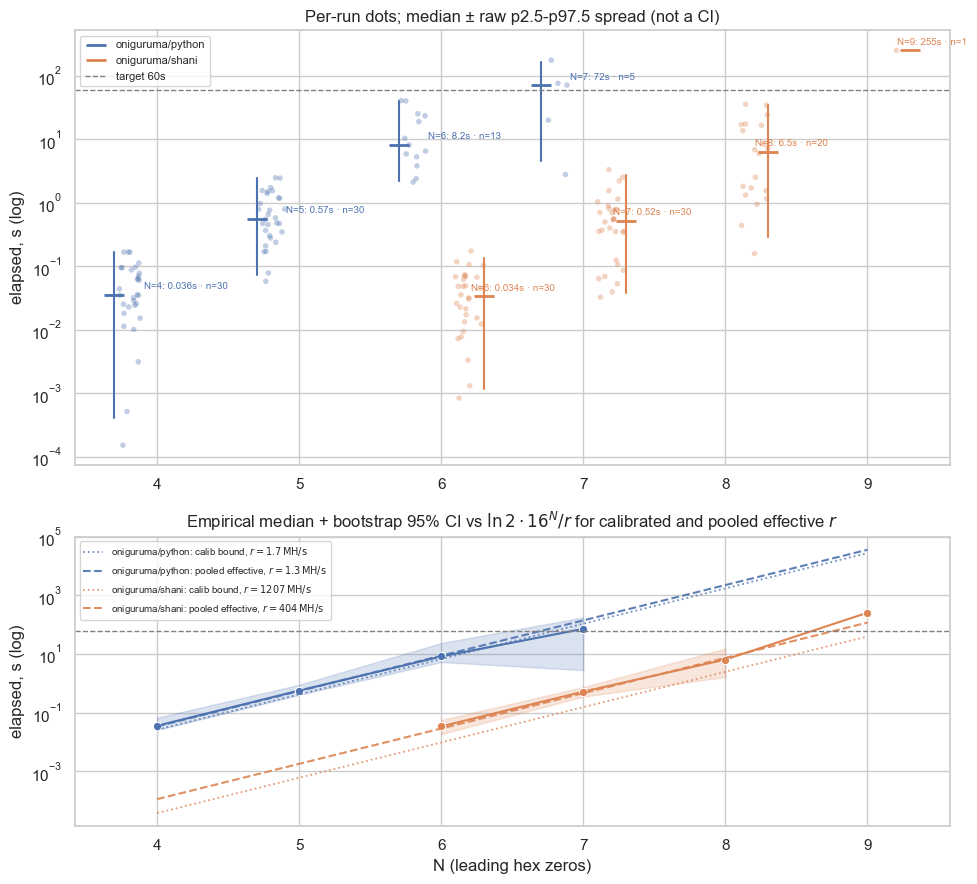

In [4]:
plot_solve_times_full(runs)

## Empirical vs theoretical distribution

Solve time is exponential in wall-clock with $\lambda = r / 16^N$. The cell below picks the largest $N$ where at least one implementation has `≥ 10` runs and overlays the empirical ECDFs onto two theoretical $\mathrm{Exp}(\lambda)$ curves per implementation: one with $r_{\mathrm{eff}}$ (dashed; what the solver actually delivers) and one with $r_{\mathrm{calib}}$ (dotted; the unattainable bound). Systematic deviation of the empirical step from the dashed line points to overhead heterogeneity; distance from the dotted line measures the coordination tax.


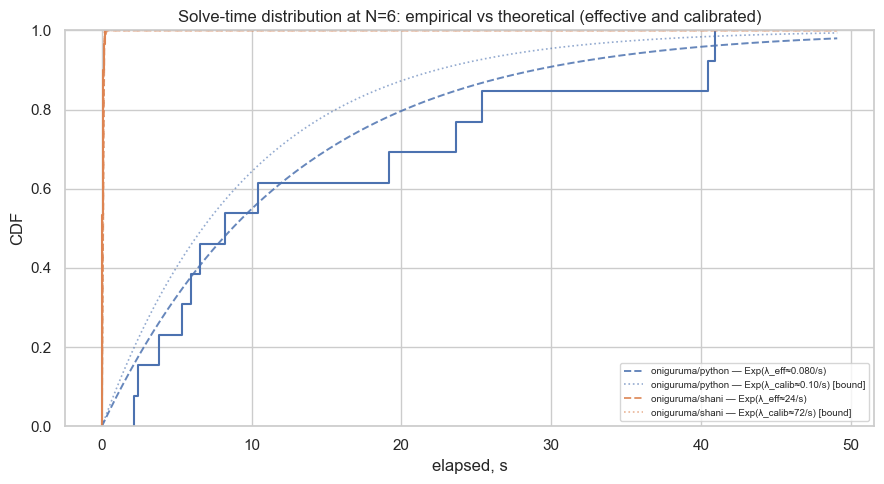

In [5]:
plot_ecdf(runs)

## Density view (diagnostic)

ECDFs can hide deviations; density plots are sharper. For the same $N$ as the ECDF above, this cell shows a per-implementation histogram restricted to `runs ≥ MIN_RUNS_TAIL`, overlaid with two theoretical $\mathrm{Exp}(\lambda)$ densities — $r_{\mathrm{eff}}$ (solid) and $r_{\mathrm{calib}}$ (dotted).


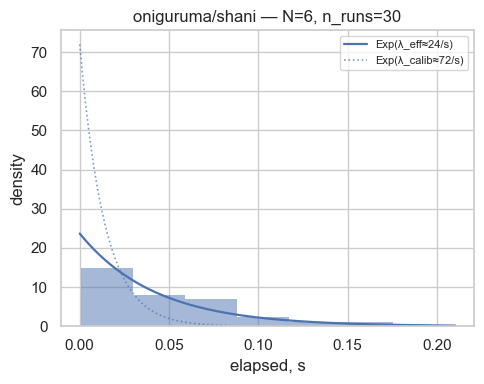

In [6]:
plot_pdf(runs)

## Normalized diagnostics

Three ratios, each of which should sit near 1 if the model is correct:

- $\mathrm{mean}(A) / 16^N$ — sanity check on the probabilistic model. Deviations point to a non-uniform digest on the leading-zero prefix, which would mean a bug in the solver.
- $\mathrm{median}(T) / (\ln 2 \cdot 16^N / r_{\mathrm{calib}})$ — solver overhead relative to the calibrated lower bound. A constant offset across $N$ is a multiplicative coordination tax; a rising trend means overhead that grows with difficulty.
- $r_{\mathrm{eff}} / r_{\mathrm{calib}}$ — the same overhead expressed as a rate ratio.

These three split *probabilistic model wrong* from *solver heavier than model*.


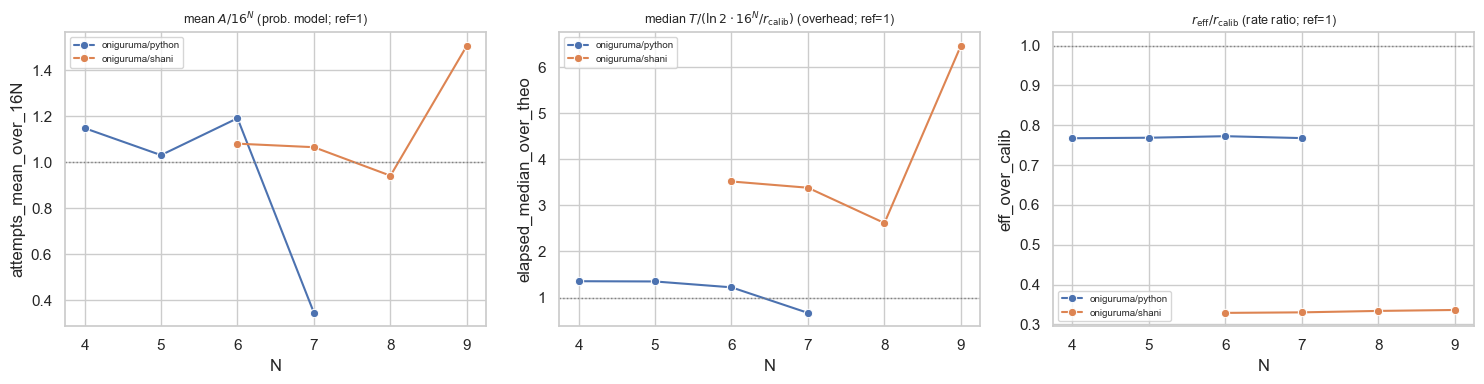

,label,n_zeros,runs,attempts_mean_over_16N,elapsed_median_over_theo,eff_over_calib
0,oniguruma/shani,6,30,1.081,3.519,0.329
1,oniguruma/shani,7,30,1.065,3.383,0.330
2,oniguruma/shani,8,20,0.941,2.617,0.334
3,oniguruma/shani,9,1,1.507,6.466,0.336
4,oniguruma/python,4,30,1.148,1.355,0.767
5,oniguruma/python,5,30,1.031,1.350,0.769
6,oniguruma/python,6,13,1.191,1.223,0.773
7,oniguruma/python,7,5,0.345,0.668,0.768


In [7]:
plot_diagnostics(runs)

## Cross-implementation comparison

Pivot of median elapsed by `(N, label)` plus two derived matrices: **relative time** against the leftmost column (lower = faster, baseline = 1) and **speedup** = baseline / this (higher = faster). Both are reported because the previous version printed only the relative-time matrix labelled as speedup, which inverts the intuition.


In [8]:
show_comparison(runs)

label,oniguruma/python,oniguruma/shani
n_zeros,,
4,0.036,—
5,0.567,—
6,8.220,0.034
7,71.889,0.522
8,—,6.455
9,—,255.184


relative time vs oniguruma/python (lower = faster):


label,oniguruma/python,oniguruma/shani
n_zeros,,
4,1.000,—
5,1.000,—
6,1.000,0.004
7,1.000,0.007
8,—,—
9,—,—


speedup vs oniguruma/python (baseline / this; higher = faster):


label,oniguruma/python,oniguruma/shani
n_zeros,,
4,1.00,—
5,1.00,—
6,1.00,242.44
7,1.00,137.83
8,—,—
9,—,—
